# Comparative Distribution and Temporal Analysis
This notebook implements the data visualization phase for the Renewable Power Plants dataset as outlined in the multi-disciplinary interim report.
It focuses on two main visualizations:
1. **Stacked Bar Charts** for comparative distribution analysis across countries.
2. **Temporal Heatmaps** for infrastructure expansion analysis.

In [2]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Dosya adın tam doğru
data_path = 'renewable_capacity_timeseries.csv'

# 1. Veriyi okuma
df = pd.read_csv(data_path)

# 2. Tarih ve zaman kırılımlarını ayarlama
df['day'] = pd.to_datetime(df['day'])
df['Year'] = df['day'].dt.year
df['Month'] = df['day'].dt.month

# 3. VERİ DÖNÜŞTÜRME (MELT)
# 'day', 'Year', 'Month' dışındaki tüm sütunları otomatik olarak kapasite sütunu kabul ediyoruz
# Böylece '_capacity' yazımındaki büyük/küçük harf hatalarının önüne geçiyoruz
exclude_cols = ['day', 'Year', 'Month']
capacity_cols = [col for col in df.columns if col not in exclude_cols]

df_melted = df.melt(id_vars=exclude_cols,
                    value_vars=capacity_cols,
                    var_name='Country_Tech',
                    value_name='Capacity_MW')

# 4. Ülke ve Teknoloji isimlerini ayrıştırma (Örn: DE_solar_capacity -> DE ve solar)
df_melted['Country'] = df_melted['Country_Tech'].apply(lambda x: x.split('_')[0])
df_melted['Technology'] = df_melted['Country_Tech'].apply(lambda x: x.split('_')[1])

# Gereksizleşen ara sütunu siliyoruz
df_melted.drop(columns=['Country_Tech'], inplace=True)

print("Veri başarıyla yüklendi ve dönüştürüldü! İlk 5 satır önizlemesi:")
print(df_melted.head())

Veri başarıyla yüklendi ve dönüştürüldü! İlk 5 satır önizlemesi:
         day  Year  Month  Capacity_MW Country Technology
0 1900-01-01  1900      1          0.0      CH  bioenergy
1 1900-01-02  1900      1          0.0      CH  bioenergy
2 1900-01-03  1900      1          0.0      CH  bioenergy
3 1900-01-04  1900      1          0.0      CH  bioenergy
4 1900-01-05  1900      1          0.0      CH  bioenergy


## 1. Comparative Distribution Analysis: Stacked Bar Chart
This section visualizes and compares the total renewable energy capacity across different countries, segmented by energy technologies for the most recent year (2020).

In [3]:
df_2020 = df_melted[df_melted['Year'] == 2020]
df_bar = df_2020.groupby(['Country', 'Technology'])['Capacity_MW'].max().reset_index()

fig = px.bar(
    df_bar,
    x="Country",
    y="Capacity_MW",
    color="Technology",
    title="Total Renewable Capacity Across Countries Segmented by Energy Sources (2020)",
    labels={"Capacity_MW": "Total Capacity (MW)", "Country": "Country", "Technology": "Energy Source"},
    barmode="stack"
)
fig.show()

## 2. Temporal Infrastructure Expansion Analysis: Heatmap
This section projects the capacity growth matrix across years and months to identify periods of rapid infrastructure development.

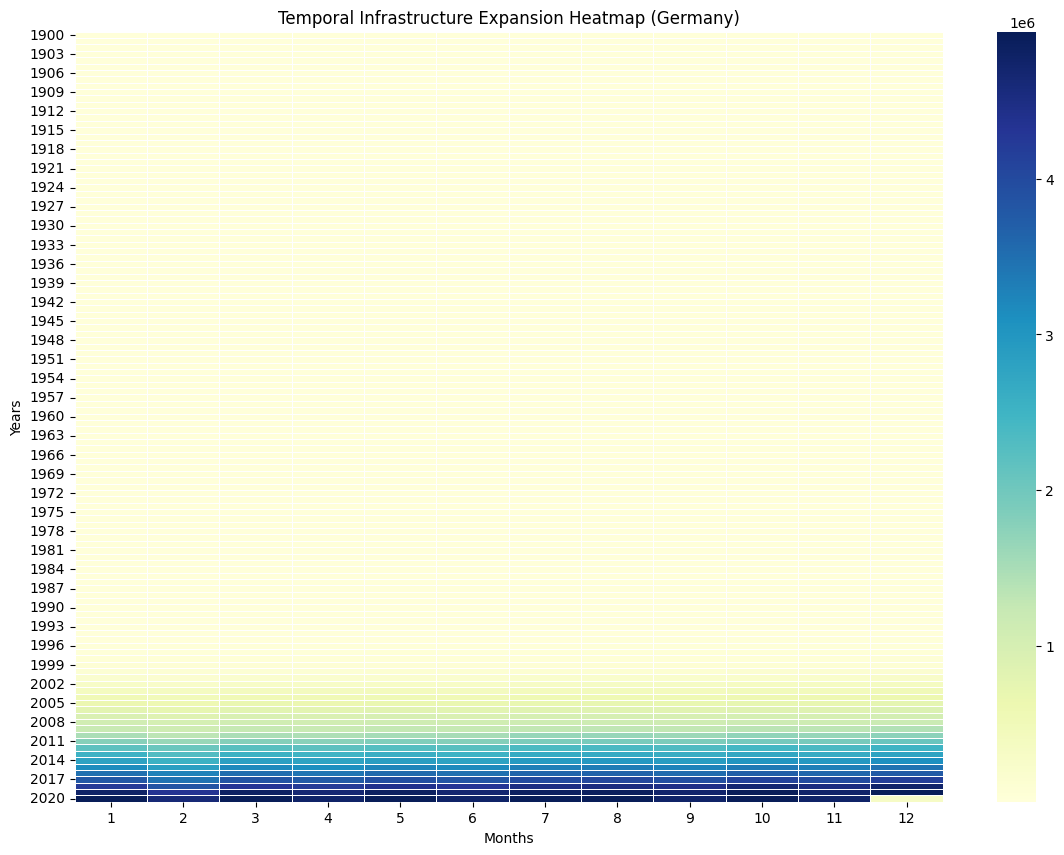

In [4]:
# Örnek ülke olarak Almanya (DE) seçilmiştir
df_heatmap_country = df_melted[df_melted['Country'] == 'DE']

pivot_heatmap = df_heatmap_country.pivot_table(
    values='Capacity_MW',
    index='Year',
    columns='Month',
    aggfunc='sum'
)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_heatmap, cmap="YlGnBu", annot=False, linewidths=.5)
plt.title("Temporal Infrastructure Expansion Heatmap (Germany)")
plt.xlabel("Months")
plt.ylabel("Years")

# Görseli dışarı aktar
plt.savefig('temporal_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Temporal and Trend Analysis: Line Chart
This section examines the growth trajectory of global renewable energy production capacity over time. By aggregating the total capacity of different technologies across the studied period, we can observe the historical milestones and acceleration points in sustainable infrastructure investments.

In [5]:
# Tüm ülkelerin yıllara göre toplam kapasite gelişimini hesaplayalım
df_trend = df_melted.groupby(['Year', 'Technology'])['Capacity_MW'].sum().reset_index()

# Plotly ile interaktif Çizgi Grafik oluşturma
fig_line = px.line(
    df_trend,
    x="Year",
    y="Capacity_MW",
    color="Technology",
    title="Temporal and Trend Analysis: Growth Trajectory of Production Capacity Over Time",
    labels={"Capacity_MW": "Total Capacity (MW)", "Year": "Years", "Technology": "Energy Source"}
)
fig_line.show()

## 4. Evolution of Energy Mix: Stacked Area Chart
While the line chart shows individual trajectories, this stacked area chart visualizes the cumulative growth and the evolving share of each renewable energy source within the global energy mix. It highlights how the dominance of certain technologies (such as Solar or Wind) has shifted over the years.

In [6]:
# Plotly ile Alan Grafiği oluşturma
fig_area = px.area(
    df_trend,
    x="Year",
    y="Capacity_MW",
    color="Technology",
    title="Evolution of Renewable Energy Source Contributions Over Time",
    labels={"Capacity_MW": "Total Capacity (MW)", "Year": "Years", "Technology": "Energy Source"}
)
fig_area.show()

## 5. Theoretical Validation: Turbine Power Curve (Scatter Plot)
To validate the underlying physical and mathematical principles of wind energy mentioned in the literature review section of our report, we simulate the "Turbine Power Curve". This scatter plot maps the empirical relationship between wind speed ($m/s$) and output power ($kW$), illustrating the non-linear, sigmoid-shaped operational efficiency of modern wind turbines.

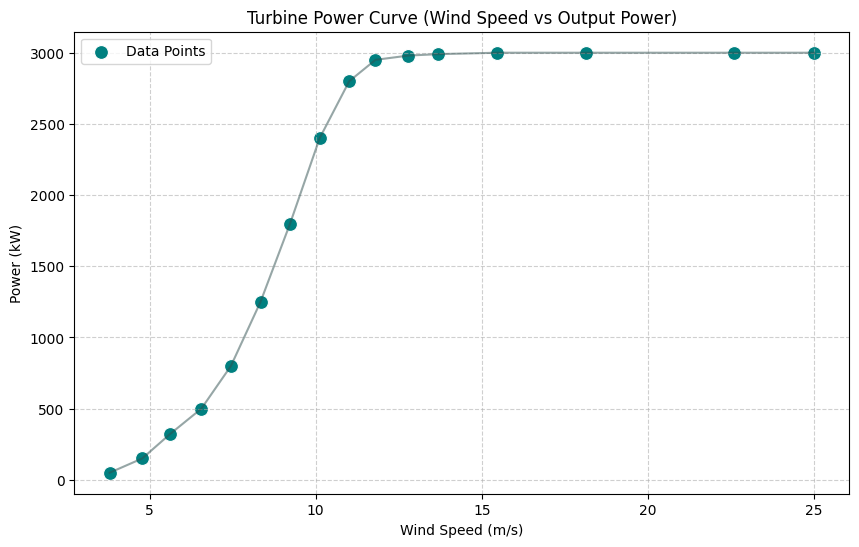

In [7]:
# Raporun Sayfa 8'indeki (Table 1.1) ve Sayfa 7'deki (Figure 1.1) verileri koda döküyoruz
turbine_data = {
    'Wind_Speed_ms': [3.8, 4.78, 5.61, 6.56, 7.45, 8.34, 9.23, 10.12, 11.01, 11.8, 12.79, 13.68, 15.46, 18.13, 22.58, 25.0],
    'Output_Power_kW': [50, 150, 320, 500, 800, 1250, 1800, 2400, 2800, 2950, 2980, 2990, 3000, 3000, 3000, 3000]
}
df_turbine = pd.DataFrame(turbine_data)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_turbine, x='Wind_Speed_ms', y='Output_Power_kW', color='teal', s=100, label='Data Points')
sns.lineplot(data=df_turbine, x='Wind_Speed_ms', y='Output_Power_kW', color='darkslategray', alpha=0.5)

plt.title("Turbine Power Curve (Wind Speed vs Output Power)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power (kW)")
plt.grid(True, linestyle='--', alpha=0.6)

# Görseli dışarı aktar
plt.savefig('turbine_power_curve.png', dpi=300, bbox_inches='tight')
plt.show()